# <font color="orange"> Coma y BAG </font>

**Cohorte coma:** solo FC AAL-116 (`.mat` en `controls`, `anoxia`, `traumatic`).

**Pipeline:**
1. Calcular **TOPO** y **Z** (mismo β-VAE) en coma y en **data** (CN, AD, FTD).
2. Entrenar (o reciclar) regresor **Ridge(Z + TOPO → edad)** usando **CN de data** como referencia de envejecimiento normativo.
3. Predecir edad cerebral en **toda** data-iipsi y en coma; comparar distribuciones (coma vs CN vs AD vs FTD).
4. Mundo pequeño (30/dx) y criticalidad en coma.

Sin edad cronológica en coma → no hay MAE/BAG clásico allí; sí **edad predicha** calibrada con el modelo aprendido en CN de data-iipsi.

In [13]:
# === Configuración ===
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sys.path.insert(0, "Thesis/Code")

from src.config import DEFAULT_PATHS, ExperimentConfig
from src.utils_seed import set_global_seed
from src.cohort import build_final_cohort_df
from src.splits import make_holdout_split
from src.data_io import load_fc_vectors_for_ids, vector_to_matrix
from src.vae_train import train_vae_final, load_vae_from_dir
from src.embeddings import encode_mu
from src.xgb_train import clean_xy
from src.metrics import regression_metrics
from src.coma_data_io import (
    list_inflamacion_mats, load_fc_vectors_from_cohort,
    TOPO_COLUMNS, DEFAULT_GROUP_MAP,
)
from src.coma_graph import compute_topo_table, threshold_fixed, threshold_proportional
from src.utils_ids import normalize_record_id

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, LeaveOneGroupOut, KFold
from sklearn.metrics import mean_absolute_error
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from joblib import Parallel, delayed

# --- Coma ---
FC_ROOT = Path("/home/usuario/disco1/proyectos/2024-autoencoders/databases/fc/inflamacion")

# --- Salidas ---
OUT = Path("outputs/nb09_coma")
FIG = Path("figs")
VAE_DIR = OUT / "vae_redlat"          # VAE entrenado en data-iipsi (compartido)
SW_OUT = OUT / "sw_metrics"
CRIT_OUT = OUT / "criticality"
for p in [OUT, FIG, VAE_DIR, SW_OUT, CRIT_OUT]:
    p.mkdir(parents=True, exist_ok=True)

paths = DEFAULT_PATHS
cfg = ExperimentConfig(seed=42, fisher_z=True, use_optuna=False)
set_global_seed(cfg.seed)
FISHER_Z = cfg.fisher_z
THRESHOLD_TOPO = 0.20

# Reciclar VAE de nb08 si existe; si no, entrenar en data-iipsi trainval
VAE_NB08 = Path("outputs/nb08_thesis/vae_final")
REUSE_VAE = True
RETRAIN_IF_MISSING = True

RIDGE_ALPHA = 267.7   # mismo orden que pipeline previo (solo Z+TOPO aquí)

# Coma — SW / criticalidad
N_PER_DX, CRIT_N_PER_DX = 30, 30
N_NULL, N_JOBS = 20, 4
PROP_CRIT = 0.10
QUICK_MODE = True

DIAG_COMA = ["CTRL", "ANOX", "TRAU"]
DIAG_REDLAT = ["CN", "AD", "FTD"]
PALETTE = {
    "CN": "#2166ac", "AD": "#d6604d", "FTD": "#4dac26",
    "CTRL": "#542788", "ANOX": "#807dba", "TRAU": "#9970ab",
    "coma": "lightblue",
    "redlat": "#FF5733",
}

def build_z_topo(Z, topo):
    return np.hstack([np.asarray(Z, np.float32), np.asarray(topo, np.float32)])

print("FC_ROOT exists:", FC_ROOT.exists())
print("data-iipsi excel:", paths.excel_path.exists())

FC_ROOT exists: True
data-iipsi excel: True


## 1. Cohorte coma — inventario y TOPO

In [3]:
cohort_coma = list_inflamacion_mats(FC_ROOT, group_map=DEFAULT_GROUP_MAP)
cohort_coma.to_csv(OUT / "cohort_coma_index.csv", index=False)
print(cohort_coma.groupby("diagnosis").size())

topo_coma = compute_topo_table(cohort_coma, threshold=THRESHOLD_TOPO, apply_fisher_z=FISHER_Z)
topo_coma.to_csv(OUT / "graph_metrics_coma.csv", index=False)
print("TOPO coma OK:", topo_coma.shape)

diagnosis
ANOX     9
CTRL    19
TRAU    14
dtype: int64
TOPO coma OK: (42, 10)


## 2. Cohorte data-iipsi — TOPO + split

In [5]:
cohort_rl = build_final_cohort_df(
    paths.excel_path, paths.fc_folder, paths.t1w_csv_path,
    diagnoses_to_use=("CN", "AD", "FTD"),
)
print("data-iipsi:", cohort_rl.shape)
print(cohort_rl.groupby("diagnosis").size())

# TOPO RedLaT (tabla nb02 si existe; si no, recalcular sería lento)
graph_path = Path("outputs/graph_metrics_table.csv")
if graph_path.exists():
    graph_rl = pd.read_csv(graph_path)
    graph_rl["record_id"] = graph_rl["MRI_ID"].map(normalize_record_id)
    graph_rl = graph_rl.drop_duplicates("record_id", keep="last")
    topo_rl = graph_rl.set_index("record_id").loc[
        cohort_rl["record_id"], TOPO_COLUMNS
    ].reset_index()
    topo_rl["diagnosis"] = cohort_rl["diagnosis"].values
    topo_rl["age"] = cohort_rl["age"].values
else:
    raise FileNotFoundError(
        "Falta outputs/graph_metrics_table.csv — correr nb02 o compute_topo en RedLaT"
    )

split = make_holdout_split(cohort_rl, seed=cfg.seed, test_size=cfg.test_size)
trainval_ids = split["trainval_ids"]
test_ids = split["test_ids"]
print(f"trainval={len(trainval_ids)} test={len(test_ids)}")

data-iipsi: (1245, 120)
diagnosis
AD     422
CN     526
FTD    297
dtype: int64
trainval=1120 test=125


## 3. β-VAE en data-iipsi (Z compartido)

El **mismo encoder** se aplica a coma y a data-iipsi para que Z sea comparable.

In [6]:
X_tv = load_fc_vectors_for_ids(paths.fc_folder, trainval_ids, apply_fisher_z=FISHER_Z)
X_te = load_fc_vectors_for_ids(paths.fc_folder, test_ids, apply_fisher_z=FISHER_Z)
X_rl_all = load_fc_vectors_for_ids(
    paths.fc_folder, cohort_rl["record_id"].tolist(), apply_fisher_z=FISHER_Z,
)

vae_src = VAE_NB08 if (REUSE_VAE and (VAE_NB08 / "vae.weights.h5").exists()) else None
if vae_src:
    import shutil
    if not (VAE_DIR / "vae.weights.h5").exists():
        shutil.copytree(vae_src, VAE_DIR, dirs_exist_ok=True)
    vae = load_vae_from_dir(VAE_DIR)
    print("VAE reciclado desde", vae_src)
elif (VAE_DIR / "vae.weights.h5").exists():
    vae = load_vae_from_dir(VAE_DIR)
    print("VAE cargado desde", VAE_DIR)
elif RETRAIN_IF_MISSING:
    VAE_HP = dict(
        hidden_dims=[512], latent_dim=64, beta_target=0.056663247229966504,
        warmup_ep=73, l2_reg=2.897389671945472e-07, lr=0.001892443497356961,
        recon_kind="mae", drop_rate=0.036861053246000725, activation="elu",
        norm_kind="layernorm", batch_size=64, clipnorm=1.0, epochs=96,
    )
    print("Entrenando VAE en data-iipsi trainval…", X_tv.shape)
    vae, _ = train_vae_final(X_tv, VAE_DIR, seed=cfg.seed, **VAE_HP)
else:
    raise FileNotFoundError("No hay VAE; set RETRAIN_IF_MISSING=True")

Z_rl = encode_mu(vae.encoder, X_rl_all)
rl_ids = cohort_rl["record_id"].tolist()
Z_rl_df = pd.DataFrame({"record_id": rl_ids, "diagnosis": cohort_rl["diagnosis"].values,
                        "age": cohort_rl["age"].values, "cohort": "redlat"})
Z_rl_df.to_csv(OUT / "z_redlat_index.csv", index=False)
np.save(OUT / "z_redlat.npy", Z_rl)
print("Z RedLaT:", Z_rl.shape)

E0000 00:00:1782761094.691259   47873 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1782761094.691527   47991 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1782761094.712141   47873 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


VAE reciclado desde outputs/nb08_thesis/vae_final
Z RedLaT: (1245, 64)


In [7]:
# Z en coma con el MISMO VAE
ids_coma = cohort_coma["record_id"].tolist()
X_coma = load_fc_vectors_from_cohort(cohort_coma, ids_coma, apply_fisher_z=FISHER_Z)
Z_coma = encode_mu(vae.encoder, X_coma)
np.save(OUT / "z_coma.npy", Z_coma)
print("Z coma:", Z_coma.shape)

topo_coma_mat = topo_coma.set_index("record_id").loc[ids_coma, TOPO_COLUMNS].to_numpy(np.float32)
topo_rl_mat = topo_rl.set_index("record_id").loc[rl_ids, TOPO_COLUMNS].to_numpy(np.float32)

Z coma: (42, 64)


## 4. Modelo Ridge(Z + TOPO → edad) — entrenado en CN data-iipsi

Referencia normativa: controles **CN** del trainval. MAE evaluable solo en data-iipsi (donde hay edad cronológica).

In [8]:
cdf = cohort_rl.set_index("record_id")
z_map = dict(zip(rl_ids, Z_rl))
topo_map = dict(zip(rl_ids, topo_rl_mat))

def pack_rl(ids):
    Z = np.stack([z_map[i] for i in ids])
    T = np.stack([topo_map[i] for i in ids])
    y = cdf.loc[ids, "age"].to_numpy(float)
    dx = cdf.loc[ids, "diagnosis"].values
    return build_z_topo(Z, T), y, dx

X_tv, y_tv, dx_tv = pack_rl(trainval_ids)
X_te, y_te, dx_te = pack_rl(test_ids)

# Entrenar solo en CN del trainval
cn_mask = dx_tv == "CN"
X_cn, y_cn = X_tv[cn_mask], y_tv[cn_mask]
print("CN trainval:", len(y_cn))

sc = StandardScaler()
ridge = Ridge(alpha=RIDGE_ALPHA, random_state=cfg.seed)
ridge.fit(sc.fit_transform(X_cn), y_cn)

# MAE en CN test (data-iipsi)
cn_te = dx_te == "CN"
pred_cn_te = ridge.predict(sc.transform(X_te[cn_te]))
mae_cn = mean_absolute_error(y_te[cn_te], pred_cn_te)
print(f"MAE CN test (data-iipsi, Z+TOPO): {mae_cn:.2f} años")

# Predicciones en toda data-iipsi
X_rl, y_rl, dx_rl = pack_rl(rl_ids)
pred_rl = ridge.predict(sc.transform(X_rl))
bag_rl = pred_rl - y_rl

pred_df = pd.DataFrame({
    "record_id": rl_ids, "cohort": "redlat", "diagnosis": dx_rl,
    "age": y_rl, "predicted_age": pred_rl, "BAG_raw": bag_rl,
})
print("\nEdad predicha RedLaT (media ± DE):")
print(pred_df.groupby("diagnosis")["predicted_age"].agg(["mean", "std", "count"]).round(2))
print("\nBAG RedLaT:")
print(pred_df.groupby("diagnosis")["BAG_raw"].agg(["mean", "std"]).round(2))

CN trainval: 473
MAE CN test (data-iipsi, Z+TOPO): 6.72 años

Edad predicha RedLaT (media ± DE):
                mean   std  count
diagnosis                        
AD         65.419998  3.85    422
CN         63.549999  4.36    526
FTD        65.559998  3.76    297

BAG RedLaT:
           mean   std
diagnosis            
AD        -4.44  9.40
CN         0.00  9.48
FTD        0.20  8.83


In [9]:
# Predicción en coma (sin edad real → solo predicted_age)
X_c = build_z_topo(Z_coma, topo_coma_mat)
pred_coma = ridge.predict(sc.transform(X_c))

pred_coma_df = pd.DataFrame({
    "record_id": ids_coma, "cohort": "coma", "diagnosis": cohort_coma["diagnosis"].values,
    "age": np.nan, "predicted_age": pred_coma,
})
# BAG relativo: desviación vs media CN RedLaT (misma escala del modelo)
ref_cn_mean = pred_df.loc[pred_df.diagnosis == "CN", "predicted_age"].mean()
pred_coma_df["BAG_vs_CN_redlat"] = pred_coma_df["predicted_age"] - ref_cn_mean

pred_all = pd.concat([pred_df, pred_coma_df], ignore_index=True)
pred_all.to_csv(OUT / "predicted_age_all_cohorts.csv", index=False)

print(f"Referencia CN RedLaT (media edad predicha): {ref_cn_mean:.2f} años")
print("\nComa — edad predicha:")
print(pred_coma_df.groupby("diagnosis")["predicted_age"].agg(["mean", "std", "count"]).round(2))
print("\nComa — BAG vs CN RedLaT:")
print(pred_coma_df.groupby("diagnosis")["BAG_vs_CN_redlat"].agg(["mean", "std"]).round(2))

Referencia CN RedLaT (media edad predicha): 63.55 años

Coma — edad predicha:
                mean   std  count
diagnosis                        
ANOX       62.080002  4.87      9
CTRL       57.680000  2.40     19
TRAU       57.389999  1.64     14

Coma — BAG vs CN RedLaT:
           mean   std
diagnosis            
ANOX      -1.47  4.87
CTRL      -5.86  2.40
TRAU      -6.15  1.64


## 5. Comparación visual: coma vs CN / AD / FTD

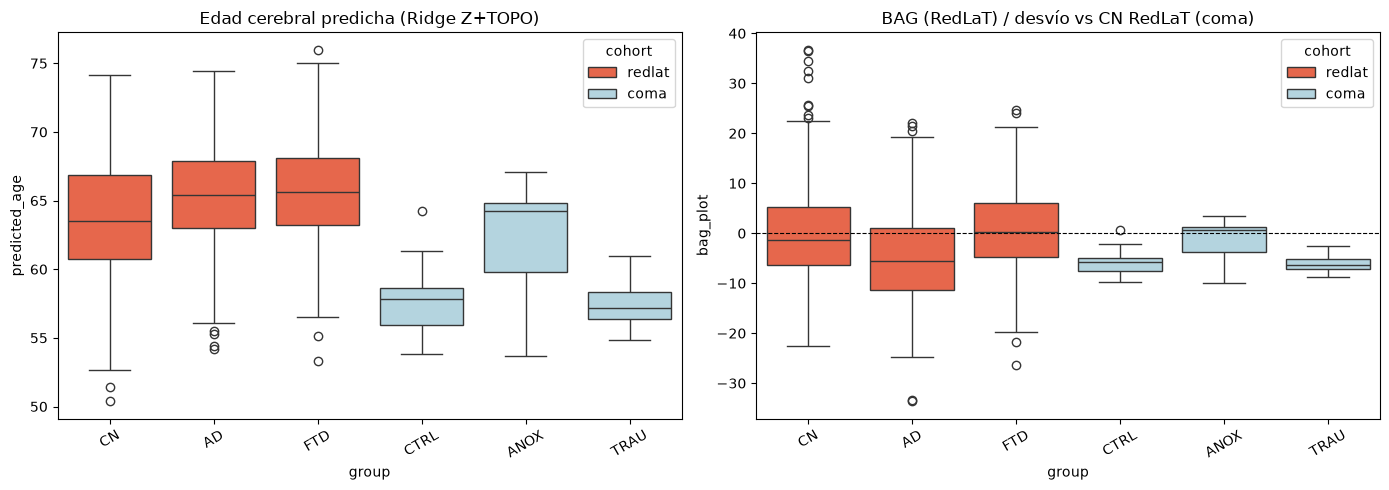

predicted_age CTRL vs CN: U-test p=3.191e-08
predicted_age CTRL vs AD: U-test p=3.551e-11
predicted_age CTRL vs FTD: U-test p=3.011e-11
predicted_age ANOX vs CN: U-test p=0.5261
predicted_age ANOX vs AD: U-test p=0.05925
predicted_age ANOX vs FTD: U-test p=0.03892
predicted_age TRAU vs CN: U-test p=2.65e-07
predicted_age TRAU vs AD: U-test p=2.84e-09
predicted_age TRAU vs FTD: U-test p=2.625e-09


In [14]:
order = ["CN", "AD", "FTD", "CTRL", "ANOX", "TRAU"]
sub = pred_all.copy()
sub["group"] = sub["diagnosis"]
sub["palette_cohort"] = sub["cohort"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Edad predicha
sns.boxplot(data=sub, x="group", y="predicted_age", order=order,
            hue="cohort", dodge=False, ax=axes[0], palette=PALETTE)
axes[0].set_title("Edad cerebral predicha (Ridge Z+TOPO)")
axes[0].tick_params(axis="x", rotation=30)

# BAG / desviación
sub_bag = sub.copy()
sub_bag["bag_plot"] = sub_bag["BAG_raw"]
sub_bag.loc[sub_bag.cohort == "coma", "bag_plot"] = sub_bag.loc[sub_bag.cohort == "coma", "BAG_vs_CN_redlat"]
sns.boxplot(data=sub_bag, x="group", y="bag_plot", order=order,
            hue="cohort", dodge=False, ax=axes[1], palette=PALETTE)
axes[1].axhline(0, color="k", ls="--", lw=0.8)
axes[1].set_title("BAG (RedLaT) / desvío vs CN RedLaT (coma)")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(FIG / "09_predicted_age_coma_vs_redlat.png", dpi=150, bbox_inches="tight")
plt.show()

# Tests: coma vs RedLaT AD/FTD en edad predicha
for g in DIAG_COMA:
    pc = pred_coma_df.loc[pred_coma_df.diagnosis == g, "predicted_age"]
    for ref in ["CN", "AD", "FTD"]:
        pr = pred_df.loc[pred_df.diagnosis == ref, "predicted_age"]
        _, p = mannwhitneyu(pc, pr, alternative="two-sided")
        print(f"predicted_age {g} vs {ref}: U-test p={p:.4g}")

## 6. TOPO en coma — comparación grupal

local_efficiency          p=0.004311
global_efficiency         p=0.05991
clustering_coeff          p=0.009429
fp_local_efficiency       p=0.06598
fp_betweenness            p=0.4853
fp_degree                 p=0.06774


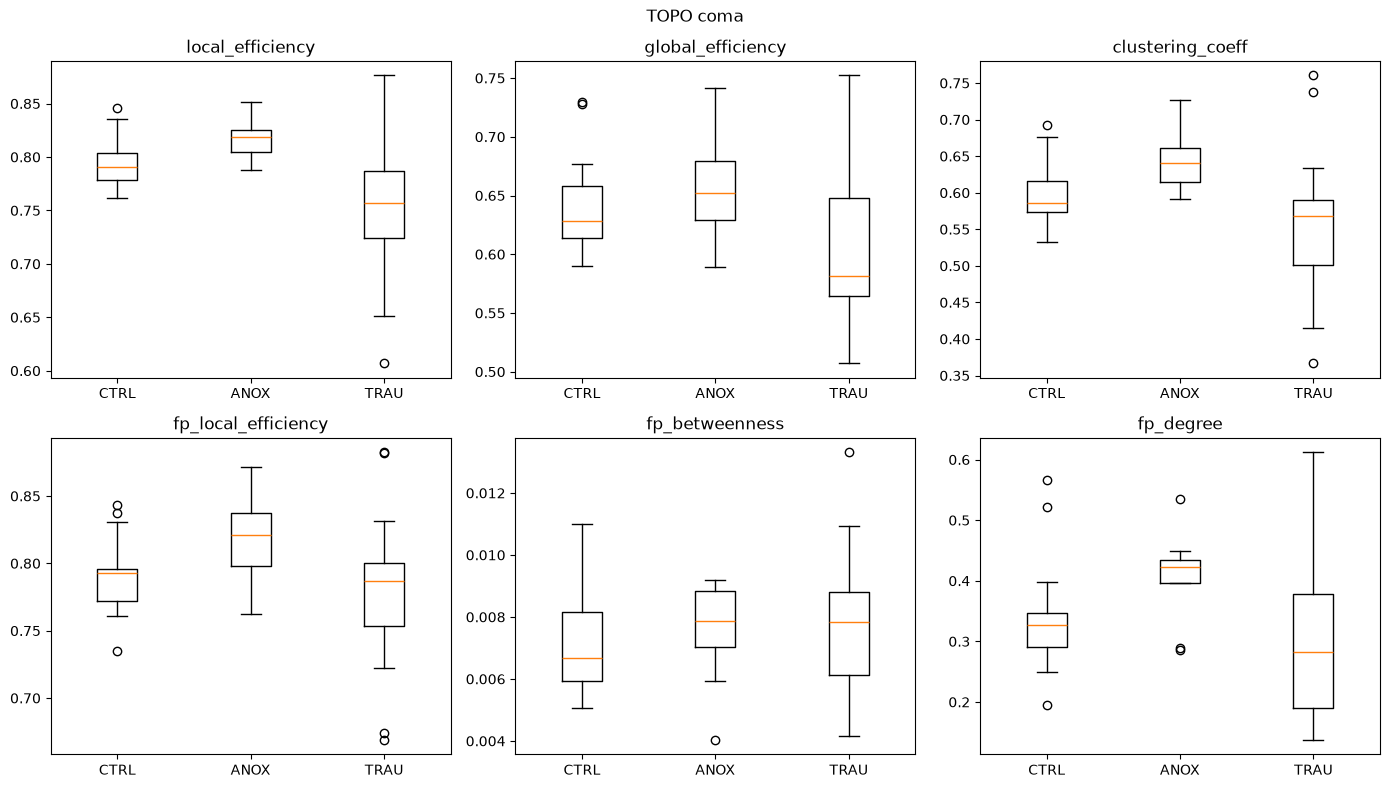

In [15]:
for m in TOPO_COLUMNS:
    groups = [topo_coma.loc[topo_coma.diagnosis == g, m].values for g in DIAG_COMA]
    H, p = kruskal(*groups)
    print(f"{m:25s} p={p:.4g}")

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, m in zip(axes.ravel(), TOPO_COLUMNS):
    data = [topo_coma.loc[topo_coma.diagnosis == g, m] for g in DIAG_COMA]
    ax.boxplot(data, tick_labels=DIAG_COMA)
    ax.set_title(m)
plt.suptitle("TOPO coma")
plt.tight_layout()
plt.savefig(FIG / "09_topo_by_diagnosis.png", dpi=150)
plt.show()

## 7. Mundo pequeño (30/dx)

In [16]:
import bct, networkx as nx

N_REWIRE = 10

def graph_metrics_sw(B):
    C = float(np.mean(bct.clustering_coef_bu(B)))
    D = bct.distance_bin(B)
    L = float(bct.charpath(D, include_diagonal=False, include_infinite=False)[0])
    return C, L

def sw_one(row, fc_z, threshold, n_null, n_rewire, seed):
    B = threshold_fixed(fc_z, threshold)
    G = nx.from_numpy_array(B)
    p = float(B.sum()) / (B.shape[0] * (B.shape[0] - 1))
    if not nx.is_connected(G) or p == 0:
        return None
    C, L = graph_metrics_sw(B)
    n = B.shape[0]
    rng = np.random.default_rng(seed + hash(row["record_id"]) % 10000)
    Cs_er, Ls_er = [], []
    for _ in range(n_null):
        G_er = nx.erdos_renyi_graph(n, p, seed=int(rng.integers(1e6)))
        B_er = nx.to_numpy_array(G_er, dtype=float)
        np.fill_diagonal(B_er, 0)
        if nx.is_connected(G_er):
            Cs_er.append(float(np.mean(bct.clustering_coef_bu(B_er))))
            d = bct.distance_bin(B_er)
            Ls_er.append(float(bct.charpath(d, include_diagonal=False, include_infinite=False)[0]))
    B_latt = (bct.latmio_und(B, n_rewire)[0] > 0).astype(float)
    np.fill_diagonal(B_latt, 0)
    C_latt = float(np.mean(bct.clustering_coef_bu(B_latt)))
    C_ws, L_ws = [], []
    for _ in range(n_null):
        B_r = (bct.randmio_und(B, n_rewire)[0] > 0).astype(float)
        np.fill_diagonal(B_r, 0)
        if nx.is_connected(nx.from_numpy_array(B_r)):
            c, l = graph_metrics_sw(B_r)
            C_ws.append(c); L_ws.append(l)
    C_er, L_er = np.nanmean(Cs_er), np.nanmean(Ls_er)
    C_ws_m, L_ws_m = np.nanmean(C_ws), np.nanmean(L_ws)
    sigma_ws = (C / C_ws_m) / (L / L_ws_m) if C_ws_m and L else np.nan
    omega_ws = (L_ws_m / L) - (C / C_latt) if L and C_latt else np.nan
    return {"record_id": row["record_id"], "diagnosis": row["diagnosis"],
            "sigma_ws": sigma_ws, "omega_ws": omega_ws}

def stratified_sample(df, n_per_dx, seed):
    return pd.concat([
        g.sample(n=min(n_per_dx, len(g)), random_state=seed)
        for _, g in df.groupby("diagnosis")
    ], ignore_index=True)

sw_sub = stratified_sample(cohort_coma[["record_id", "diagnosis"]], N_PER_DX, cfg.seed) if QUICK_MODE else cohort_coma
fc_z_map = {rid: vector_to_matrix(load_fc_vectors_from_cohort(cohort_coma, [rid], apply_fisher_z=FISHER_Z)[0])
            for rid in sw_sub["record_id"]}
rows_sw = Parallel(n_jobs=N_JOBS)(
    delayed(sw_one)(r.to_dict(), fc_z_map[r["record_id"]], THRESHOLD_TOPO, N_NULL, N_REWIRE, cfg.seed)
    for _, r in sw_sub.iterrows()
)
sw_df = pd.DataFrame([x for x in rows_sw if x])
sw_df.to_csv(SW_OUT / "sw_metrics.csv", index=False)
print(sw_df.groupby("diagnosis")[["sigma_ws", "omega_ws"]].mean().round(3))

           sigma_ws  omega_ws
diagnosis                    
ANOX          1.383     0.074
CTRL          1.630     0.111
TRAU          1.582     0.140


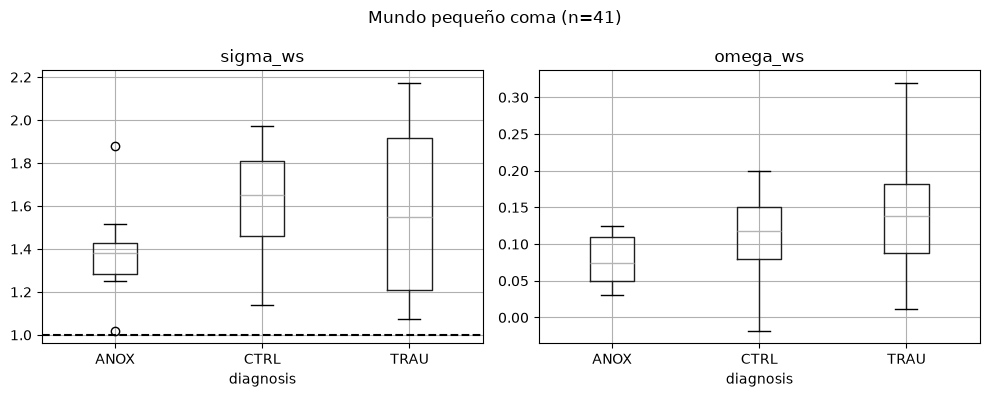

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, ["sigma_ws", "omega_ws"]):
    sw_df.boxplot(column=col, by="diagnosis", ax=ax)
    if col == "sigma_ws":
        ax.axhline(1, color="k", ls="--")
plt.suptitle(f"Mundo pequeño coma (n={len(sw_df)})")
plt.tight_layout()
plt.savefig(FIG / "09_sw_by_diagnosis.png", dpi=150)
plt.show()

## 8. Criticalidad (coma)

diagnosis
ANOX    21.98
CTRL    17.37
TRAU    18.38
Name: lambda1, dtype: float64


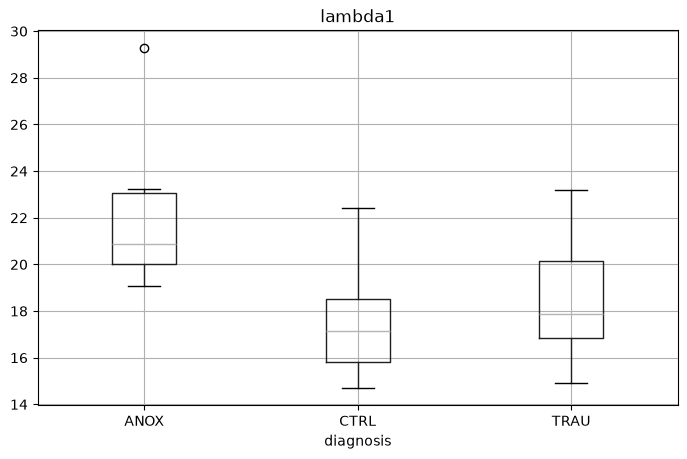

Pipeline completo. Salidas: outputs/nb09_coma


In [18]:
N_ROI = 116
ids_c = cohort_coma["record_id"].tolist()
fc_z_crit = {rid: vector_to_matrix(v) for rid, v in zip(
    ids_c, load_fc_vectors_from_cohort(cohort_coma, ids_c, apply_fisher_z=FISHER_Z))}

lambda1_df = pd.DataFrame([
    {"record_id": rid, "diagnosis": cohort_coma.set_index("record_id").loc[rid, "diagnosis"],
     "lambda1": float(np.linalg.eigvalsh(threshold_proportional(fc_z_crit[rid], PROP_CRIT))[-1])}
    for rid in ids_c
])
lambda1_df.to_csv(CRIT_OUT / "metricas_criticalidad.csv", index=False)
print(lambda1_df.groupby("diagnosis")["lambda1"].mean().round(2))

crit_sub = stratified_sample(cohort_coma[["record_id", "diagnosis"]], CRIT_N_PER_DX, cfg.seed)
PROPS = np.round(np.concatenate([np.arange(0.002, 0.032, 0.002), np.arange(0.04, 0.21, 0.01)]), 3)

def perc_one(row, fc_z, props):
    out = []
    for prop in props:
        B = threshold_proportional(fc_z, prop)
        comps = sorted(nx.connected_components(nx.from_numpy_array(B)), key=len, reverse=True)
        S2 = len(comps[1]) / N_ROI if len(comps) >= 2 else 0.0
        out.append({"record_id": row["record_id"], "diagnosis": row["diagnosis"],
                    "prop": prop, "chi": S2**2 / N_ROI})
    return out

perc_df = pd.DataFrame([r for sub in Parallel(n_jobs=N_JOBS)(
    delayed(perc_one)(row.to_dict(), fc_z_crit[row["record_id"]], PROPS)
    for _, row in crit_sub.iterrows()) for r in sub])
perc_df.to_csv(CRIT_OUT / "percolacion.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))
lambda1_df.boxplot(column="lambda1", by="diagnosis", ax=ax)
plt.suptitle("")
plt.savefig(FIG / "09_crit_lambda1.png", dpi=150)
plt.show()

meta = {
    "mae_cn_test_redlat": float(mae_cn),
    "ref_cn_pred_mean": float(ref_cn_mean),
    "n_coma": int(len(cohort_coma)),
    "n_redlat": int(len(cohort_rl)),
    "features": "Z+TOPO",
    "train_reference": "CN data-iipsi trainval",
}
with open(OUT / "transfer_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
print("Pipeline completo. Salidas:", OUT)